#Задание

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке.  Используйте следующее деление: обучающая выборка - **50000** примеров, проверочная выборка - **10000** примеров, тестовая выборка - **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведенных тестов.

## Импорт библиотек + загрузка данных

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=256)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

## Описание базы

### База: одежда, обувь и аксессуары
- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в numpy-массиве **(28, 28)** - **x_train, x_test**.
- База содержит **10** классов: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны) - **y_train, y_test**.
- Примеров: train - **60000**, test - **10000**.

## Визуализация

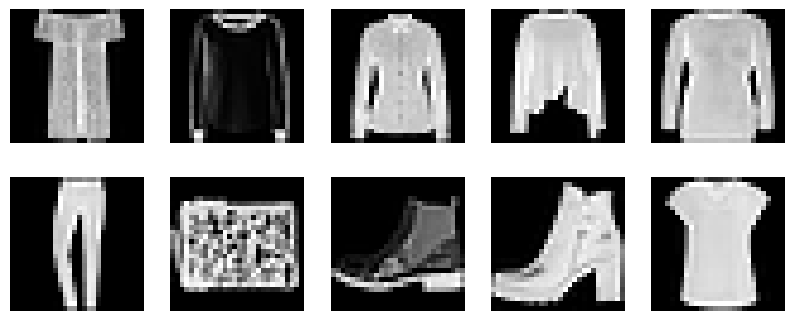

In [27]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

## Функции обучения

In [28]:
def train_model(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc_hist = []
    val_acc_hist = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            if batch_idx > 100:  # ускорение
                break

        train_acc = correct / total
        train_acc_hist.append(train_acc)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)

                _, preds = torch.max(outputs, 1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        val_acc_hist.append(val_acc)

        print(f"Эпоха {epoch+1}: train={train_acc:.4f}, val={val_acc:.4f}")

    return train_acc_hist, val_acc_hist

In [29]:
def test_model(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

## Модель 1 - Базовая полносвязная нейронная сеть (Dense)

Эпоха 1: train=0.6919, val=0.7864
Эпоха 2: train=0.8101, val=0.8104
Эпоха 3: train=0.8314, val=0.8254
Эпоха 4: train=0.8372, val=0.8296
Эпоха 5: train=0.8450, val=0.8391
Эпоха 6: train=0.8491, val=0.8421
Эпоха 7: train=0.8569, val=0.8433
Эпоха 8: train=0.8589, val=0.8426
Эпоха 9: train=0.8618, val=0.8507
Эпоха 10: train=0.8626, val=0.8495
Эпоха 11: train=0.8714, val=0.8529
Эпоха 12: train=0.8663, val=0.8561
Эпоха 13: train=0.8739, val=0.8582
Эпоха 14: train=0.8741, val=0.8522
Эпоха 15: train=0.8711, val=0.8579
Эпоха 16: train=0.8740, val=0.8613
Эпоха 17: train=0.8773, val=0.8607
Эпоха 18: train=0.8783, val=0.8639
Эпоха 19: train=0.8793, val=0.8616
Эпоха 20: train=0.8811, val=0.8656


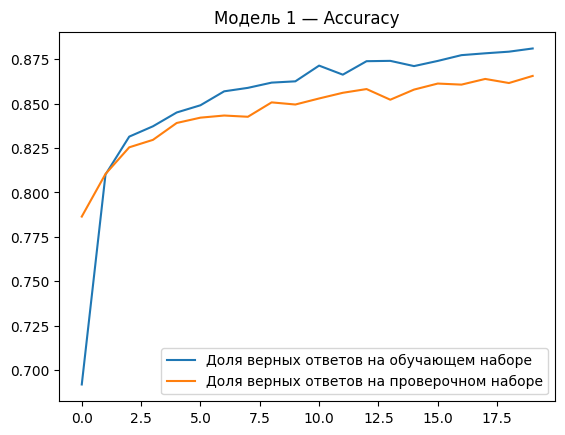

In [31]:
class Model1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model1 = Model1().to(device)
train1, val1 = train_model(model1, train_loader, val_loader)
test1 = test_model(model1, test_loader)

plt.plot(train1, label="Доля верных ответов на обучающем наборе")
plt.plot(val1, label="Доля верных ответов на проверочном наборе")
plt.legend()
plt.title("Модель 1 — Accuracy")
plt.show()

## Модель 2 - Полносвязная сеть с регуляризацией Dropout

Эпоха 1: train=0.6324, val=0.7626
Эпоха 2: train=0.7786, val=0.7981
Эпоха 3: train=0.8033, val=0.8191
Эпоха 4: train=0.8223, val=0.8256
Эпоха 5: train=0.8308, val=0.8358
Эпоха 6: train=0.8371, val=0.8431
Эпоха 7: train=0.8458, val=0.8497
Эпоха 8: train=0.8456, val=0.8453
Эпоха 9: train=0.8500, val=0.8521
Эпоха 10: train=0.8547, val=0.8538
Эпоха 11: train=0.8559, val=0.8581
Эпоха 12: train=0.8563, val=0.8583
Эпоха 13: train=0.8574, val=0.8598
Эпоха 14: train=0.8606, val=0.8622
Эпоха 15: train=0.8619, val=0.8583
Эпоха 16: train=0.8652, val=0.8591
Эпоха 17: train=0.8653, val=0.8679
Эпоха 18: train=0.8650, val=0.8637
Эпоха 19: train=0.8657, val=0.8671
Эпоха 20: train=0.8645, val=0.8655


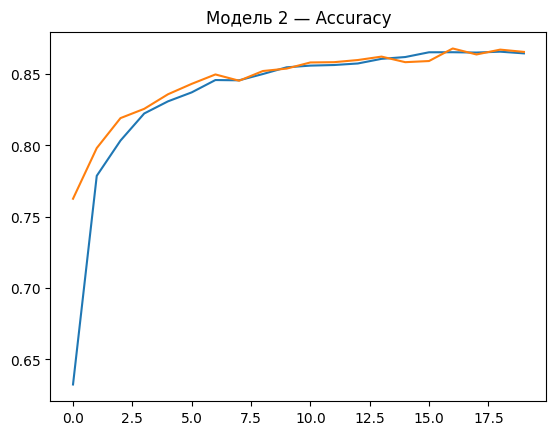

In [32]:
class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model2 = Model2().to(device)
train2, val2 = train_model(model2, train_loader, val_loader)
test2 = test_model(model2, test_loader)

plt.plot(train2, label="Доля верных ответов на обучающем наборе")
plt.plot(val2, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 2 — Accuracy")
plt.show()

## Модель 3 - Полносвязная сеть с Batch Normalization и Dropout

Эпоха 1: train=0.7628, val=0.8188
Эпоха 2: train=0.8420, val=0.8410
Эпоха 3: train=0.8598, val=0.8488
Эпоха 4: train=0.8638, val=0.8503
Эпоха 5: train=0.8714, val=0.8500
Эпоха 6: train=0.8771, val=0.8639
Эпоха 7: train=0.8847, val=0.8642
Эпоха 8: train=0.8884, val=0.8552
Эпоха 9: train=0.8894, val=0.8662
Эпоха 10: train=0.8916, val=0.8489
Эпоха 11: train=0.8950, val=0.8687
Эпоха 12: train=0.8996, val=0.8646
Эпоха 13: train=0.8996, val=0.8526
Эпоха 14: train=0.9025, val=0.8616
Эпоха 15: train=0.9059, val=0.8648
Эпоха 16: train=0.9084, val=0.8685
Эпоха 17: train=0.9094, val=0.8737
Эпоха 18: train=0.9136, val=0.8635
Эпоха 19: train=0.9140, val=0.8764
Эпоха 20: train=0.9138, val=0.8678


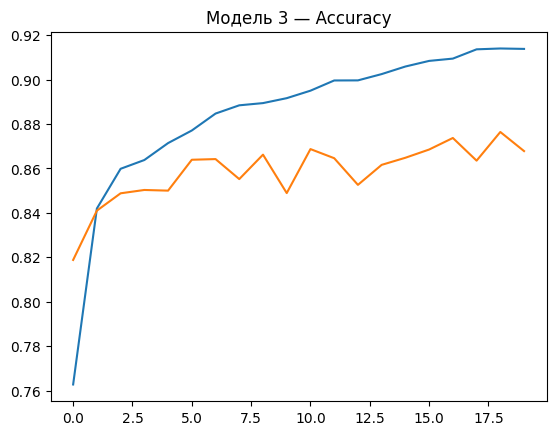

In [33]:
class Model3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model3 = Model3().to(device)
train3, val3 = train_model(model3, train_loader, val_loader)
test3 = test_model(model3, test_loader)

plt.plot(train3, label="Доля верных ответов на обучающем наборе")
plt.plot(val3, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 3 — Accuracy")
plt.show()

## Модель 4 - Углубленная полносвязная нейронная сеть

Эпоха 1: train=0.6634, val=0.7868
Эпоха 2: train=0.8088, val=0.8233
Эпоха 3: train=0.8388, val=0.8304
Эпоха 4: train=0.8456, val=0.8400
Эпоха 5: train=0.8543, val=0.8368
Эпоха 6: train=0.8582, val=0.8424
Эпоха 7: train=0.8612, val=0.8500
Эпоха 8: train=0.8650, val=0.8579
Эпоха 9: train=0.8690, val=0.8637
Эпоха 10: train=0.8738, val=0.8671
Эпоха 11: train=0.8753, val=0.8635
Эпоха 12: train=0.8758, val=0.8660
Эпоха 13: train=0.8808, val=0.8638
Эпоха 14: train=0.8787, val=0.8709
Эпоха 15: train=0.8836, val=0.8741
Эпоха 16: train=0.8893, val=0.8690
Эпоха 17: train=0.8903, val=0.8733
Эпоха 18: train=0.8917, val=0.8741
Эпоха 19: train=0.8921, val=0.8742
Эпоха 20: train=0.8952, val=0.8775


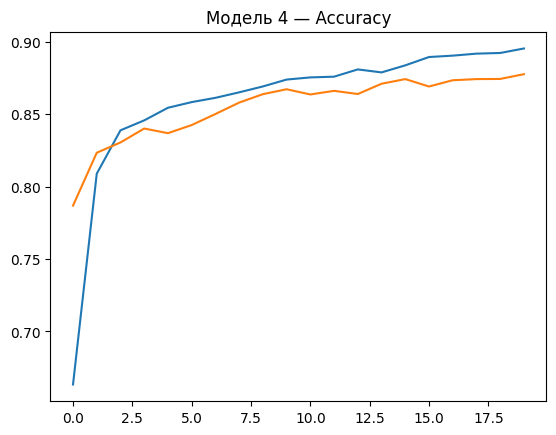

In [34]:
class Model4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model4 = Model4().to(device)
train4, val4 = train_model(model4, train_loader, val_loader)
test4 = test_model(model4, test_loader)

plt.plot(train4, label="Доля верных ответов на обучающем наборе")
plt.plot(val4, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 4 — Accuracy")
plt.show()

## Модель 5 - Базовая сверточная нейронная сеть (CNN)

Эпоха 1: train=0.6638, val=0.7593
Эпоха 2: train=0.7907, val=0.8045
Эпоха 3: train=0.8236, val=0.8172
Эпоха 4: train=0.8375, val=0.8313
Эпоха 5: train=0.8443, val=0.8390
Эпоха 6: train=0.8524, val=0.8467
Эпоха 7: train=0.8555, val=0.8490
Эпоха 8: train=0.8558, val=0.8513
Эпоха 9: train=0.8580, val=0.8502
Эпоха 10: train=0.8627, val=0.8539
Эпоха 11: train=0.8658, val=0.8580
Эпоха 12: train=0.8645, val=0.8543
Эпоха 13: train=0.8659, val=0.8571
Эпоха 14: train=0.8706, val=0.8552
Эпоха 15: train=0.8703, val=0.8623
Эпоха 16: train=0.8724, val=0.8622
Эпоха 17: train=0.8721, val=0.8591
Эпоха 18: train=0.8702, val=0.8630
Эпоха 19: train=0.8727, val=0.8624
Эпоха 20: train=0.8766, val=0.8634


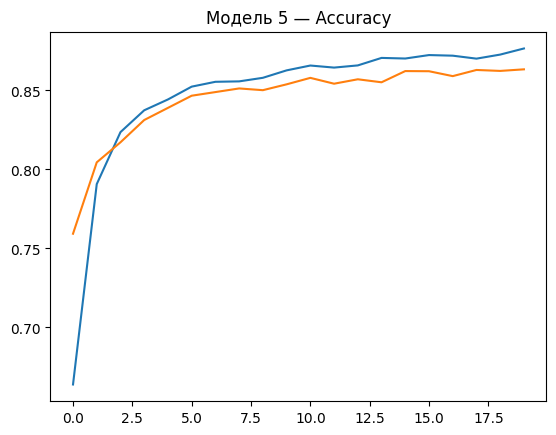

In [35]:
class Model5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8*13*13, 10)
        )
    def forward(self, x): return self.net(x)

model5 = Model5().to(device)
train5, val5 = train_model(model5, train_loader, val_loader)
test5 = test_model(model5, test_loader)

plt.plot(train5, label="Доля верных ответов на обучающем наборе")
plt.plot(val5, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 5 — Accuracy")
plt.show()

## Модель 6 - Сверточная сеть с регуляризацией Dropout

Эпоха 1: train=0.6591, val=0.7659
Эпоха 2: train=0.7861, val=0.7992
Эпоха 3: train=0.8142, val=0.8271
Эпоха 4: train=0.8292, val=0.8391
Эпоха 5: train=0.8339, val=0.8432
Эпоха 6: train=0.8453, val=0.8533
Эпоха 7: train=0.8493, val=0.8555
Эпоха 8: train=0.8530, val=0.8517
Эпоха 9: train=0.8545, val=0.8616
Эпоха 10: train=0.8572, val=0.8626
Эпоха 11: train=0.8599, val=0.8641
Эпоха 12: train=0.8618, val=0.8634
Эпоха 13: train=0.8662, val=0.8685
Эпоха 14: train=0.8664, val=0.8642
Эпоха 15: train=0.8647, val=0.8707
Эпоха 16: train=0.8701, val=0.8731
Эпоха 17: train=0.8705, val=0.8719
Эпоха 18: train=0.8707, val=0.8725
Эпоха 19: train=0.8698, val=0.8758
Эпоха 20: train=0.8696, val=0.8741


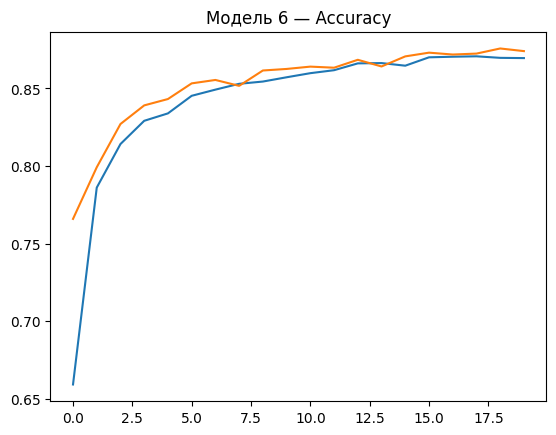

In [36]:
class Model6(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(8*13*13, 10)
        )
    def forward(self, x): return self.net(x)

model6 = Model6().to(device)
train6, val6 = train_model(model6, train_loader, val_loader)
test6 = test_model(model6, test_loader)

plt.plot(train6, label="Доля верных ответов на обучающем наборе")
plt.plot(val6, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 6 — Accuracy")
plt.show()

## Модель 7 - Сверточная сеть с Batch Normalization и Dropout

Эпоха 1: train=0.7787, val=0.8416
Эпоха 2: train=0.8586, val=0.8645
Эпоха 3: train=0.8742, val=0.8748
Эпоха 4: train=0.8834, val=0.8779
Эпоха 5: train=0.8892, val=0.8737
Эпоха 6: train=0.8945, val=0.8834
Эпоха 7: train=0.8972, val=0.8744
Эпоха 8: train=0.9002, val=0.8860
Эпоха 9: train=0.9043, val=0.8854
Эпоха 10: train=0.9079, val=0.8861
Эпоха 11: train=0.9069, val=0.8821
Эпоха 12: train=0.9099, val=0.8917
Эпоха 13: train=0.9090, val=0.8900
Эпоха 14: train=0.9130, val=0.8905
Эпоха 15: train=0.9158, val=0.8939
Эпоха 16: train=0.9141, val=0.8904
Эпоха 17: train=0.9186, val=0.8936
Эпоха 18: train=0.9155, val=0.8809
Эпоха 19: train=0.9193, val=0.8884
Эпоха 20: train=0.9193, val=0.8915


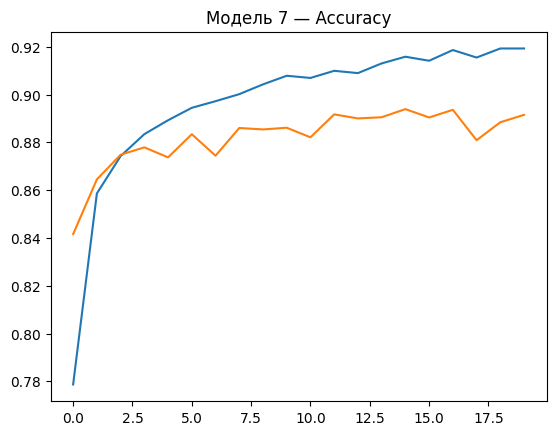

In [37]:
class Model7(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8*13*13, 10)
        )
    def forward(self, x): return self.net(x)

model7 = Model7().to(device)
train7, val7 = train_model(model7, train_loader, val_loader)
test7 = test_model(model7, test_loader)

plt.plot(train7, label="Доля верных ответов на обучающем наборе")
plt.plot(val7, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 7 — Accuracy")
plt.show()

## Модель 8 - Углубленная сверточная сеть с Global Average Pooling

Эпоха 1: train=0.1209, val=0.0865
Эпоха 2: train=0.1090, val=0.1373
Эпоха 3: train=0.1615, val=0.1996
Эпоха 4: train=0.2166, val=0.2312
Эпоха 5: train=0.2747, val=0.3086
Эпоха 6: train=0.3306, val=0.3367
Эпоха 7: train=0.3491, val=0.3325
Эпоха 8: train=0.3713, val=0.3612
Эпоха 9: train=0.3841, val=0.3944
Эпоха 10: train=0.4071, val=0.3924
Эпоха 11: train=0.4170, val=0.4218
Эпоха 12: train=0.4384, val=0.4238
Эпоха 13: train=0.4458, val=0.4204
Эпоха 14: train=0.4568, val=0.4434
Эпоха 15: train=0.4682, val=0.4801
Эпоха 16: train=0.4780, val=0.4832
Эпоха 17: train=0.4915, val=0.4948
Эпоха 18: train=0.4986, val=0.4919
Эпоха 19: train=0.5072, val=0.5103
Эпоха 20: train=0.5129, val=0.5018


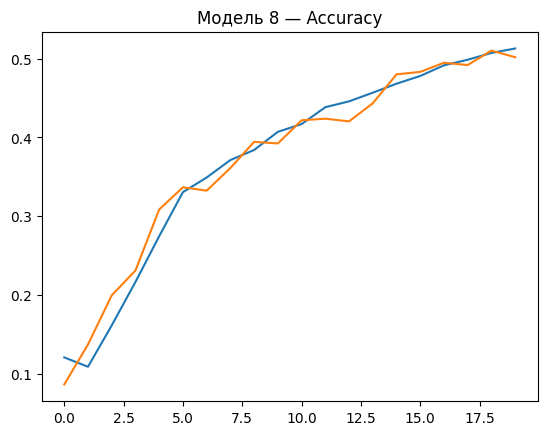

In [38]:
class Model8(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(16, 10)
        )
    def forward(self, x): return self.net(x)

model8 = Model8().to(device)
train8, val8 = train_model(model8, train_loader, val_loader)
test8 = test_model(model8, test_loader)

plt.plot(train8, label="Доля верных ответов на обучающем наборе")
plt.plot(val8, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 8 — Accuracy")
plt.show()

## Модель 9 - Глубокая сверточная сеть с улучшенной архитектурой

Эпоха 1: train=0.7482, val=0.8233
Эпоха 2: train=0.8511, val=0.8556
Эпоха 3: train=0.8693, val=0.8662
Эпоха 4: train=0.8807, val=0.8743
Эпоха 5: train=0.8878, val=0.8821
Эпоха 6: train=0.8901, val=0.8818
Эпоха 7: train=0.8957, val=0.8817
Эпоха 8: train=0.9000, val=0.8840
Эпоха 9: train=0.9052, val=0.8861
Эпоха 10: train=0.9055, val=0.8932
Эпоха 11: train=0.9064, val=0.8952
Эпоха 12: train=0.9115, val=0.8938
Эпоха 13: train=0.9122, val=0.8978
Эпоха 14: train=0.9160, val=0.8949
Эпоха 15: train=0.9173, val=0.8985
Эпоха 16: train=0.9195, val=0.9018
Эпоха 17: train=0.9178, val=0.9019
Эпоха 18: train=0.9244, val=0.8976
Эпоха 19: train=0.9247, val=0.8988
Эпоха 20: train=0.9267, val=0.9027


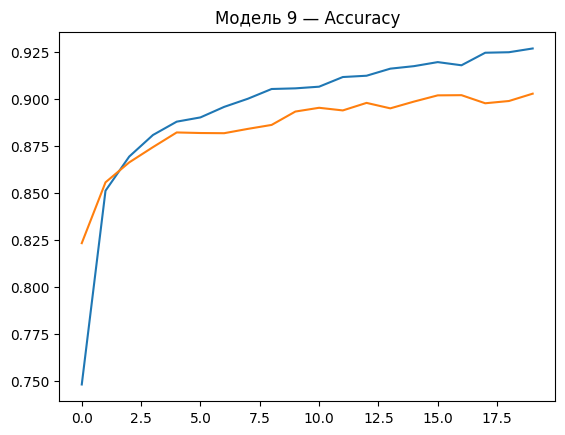

In [39]:
class Model9(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*12*12, 10)
        )
    def forward(self, x): return self.net(x)

model9 = Model9().to(device)
train9, val9 = train_model(model9, train_loader, val_loader)
test9 = test_model(model9, test_loader)

plt.plot(train9, label="Доля верных ответов на обучающем наборе")
plt.plot(val9, label="Доля верных ответов на проверочном наборе")
plt.title("Модель 9 — Accuracy")
plt.show()

## Сравнительная таблица

In [40]:
df = pd.DataFrame({
    "Модель": [f"M{i}" for i in range(1,10)],
    "Val": [val1[-1], val2[-1], val3[-1], val4[-1],
            val5[-1], val6[-1], val7[-1], val8[-1], val9[-1]],
    "Test": [test1, test2, test3, test4,
             test5, test6, test7, test8, test9]
})

df

,Модель,Val,Test
0,M1,0.8656,0.8601
1,M2,0.8655,0.8596
2,M3,0.8678,0.8594
3,M4,0.8775,0.8734
4,M5,0.8634,0.8633
5,M6,0.8741,0.8733
6,M7,0.8915,0.8876
7,M8,0.5018,0.5006
8,M9,0.9027,0.9029
